# LIMUC VLM zero-shot severity (Mayo score)
Run a vision-language model zero-shot to predict MES (0-3). Output format: `SCORE: X`.


In [1]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"
os.environ["TRANSFORMERS_NO_JAX"] = "1"
os.environ["USE_TF"] = "0"

import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
from transformers import AutoProcessor
try:
    from transformers import AutoModelForVision2Seq
    _HAS_VISION2SEQ = True
except Exception:
    from transformers import Blip2ForConditionalGeneration
    AutoModelForVision2Seq = None
    _HAS_VISION2SEQ = False


In [2]:
# Paths & config
def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root containing '0_dataset_prep'. cwd={start}")

DATA_ROOT = find_dataset_root()
META_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "metadata_enriched.csv"
LABEL_MAP_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "label_map.csv"
OUT_DIR = DATA_ROOT / "3_vlm_severity" / "out" / "vlm_zero_shot_mayo"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = os.getenv("VLM_MODEL", "Salesforce/blip2-flan-t5-xl")
FORCE_CUDA = int(os.getenv("FORCE_CUDA", "1"))
if FORCE_CUDA and not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available in this Python environment. "
        "Install a CUDA-enabled PyTorch build and restart the kernel."
    )
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
MODEL_DTYPE = torch.bfloat16 if USE_BF16 else (torch.float16 if torch.cuda.is_available() else None)
if DEVICE.type == "cuda":
    torch.cuda.set_device(0)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

MAX_NEW_TOKENS = int(os.getenv("MAX_NEW_TOKENS", "10"))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "1"))
MAX_SAMPLES = int(os.getenv("MAX_SAMPLES", "0")) or None
SEED = int(os.getenv("SEED", "42"))
PROCESSOR_USE_FAST = int(os.getenv("PROCESSOR_USE_FAST", "1"))

PROMPT = (
    "You are a medical expert. Given this colonoscopy image, provide the Mayo Endoscopic Score (0-3). "
    "Respond with only: 'SCORE: X' where X is 0,1,2, or 3."
)

print("Model:", MODEL_NAME)
print("Output dir:", OUT_DIR)


Using GPU: NVIDIA GeForce RTX 3090
Model: Salesforce/blip2-flan-t5-xl
Output dir: /mnt/hf/thesis/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/LIMUC/3_vlm_severity/out/vlm_zero_shot_mayo


In [3]:
# Seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load metadata
meta = pd.read_csv(META_CSV)
images_base = DATA_ROOT / "0_dataset_prep"

def to_abs(p):
    p = Path(p)
    if p.is_absolute():
        return p
    return (images_base / p).resolve()

meta["image_path"] = meta["image_path"].apply(lambda p: str(to_abs(p)))

# Label map
if LABEL_MAP_CSV.exists():
    label_map = pd.read_csv(LABEL_MAP_CSV)
    id_to_name = dict(zip(label_map.label_id, label_map.label_name))
else:
    id_to_name = {i: name for i, name in enumerate(sorted(meta.label_name.unique()))}

name_to_id = {v: k for k, v in id_to_name.items()}
meta["label_id"] = meta["label_name"].map(name_to_id)

meta = meta[meta["image_path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)
if MAX_SAMPLES:
    meta = meta.sample(n=min(MAX_SAMPLES, len(meta)), random_state=SEED).reset_index(drop=True)

val_df = meta[meta["split"] == "val"].reset_index(drop=True)
test_df = meta[meta["split"] == "test"].reset_index(drop=True)

print("Val/Test:", len(val_df), len(test_df))


Val/Test: 921 1686


In [4]:
processor = AutoProcessor.from_pretrained(MODEL_NAME, use_fast=bool(PROCESSOR_USE_FAST))

if MODEL_DTYPE is not None:
    if _HAS_VISION2SEQ:
        model = AutoModelForVision2Seq.from_pretrained(MODEL_NAME, torch_dtype=MODEL_DTYPE)
    else:
        model = Blip2ForConditionalGeneration.from_pretrained(MODEL_NAME, torch_dtype=MODEL_DTYPE)
else:
    if _HAS_VISION2SEQ:
        model = AutoModelForVision2Seq.from_pretrained(MODEL_NAME)
    else:
        model = Blip2ForConditionalGeneration.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()


def parse_score(text: str):
    if text is None:
        return None
    m = re.search(r"\b(?:SCORE\s*:\s*)?([0-3])\b", text, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))
    return None


def run_split(df: pd.DataFrame):
    y_true, y_pred, preds_text = [], [], []
    for start in range(0, len(df), BATCH_SIZE):
        batch_df = df.iloc[start:start + BATCH_SIZE]
        imgs = [Image.open(p).convert("RGB") for p in batch_df.image_path.values]
        prompts = [PROMPT] * len(imgs)
        inputs = processor(images=imgs, text=prompts, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad():
            generated = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
            )
        texts = processor.batch_decode(generated, skip_special_tokens=True)
        for row, text in zip(batch_df.itertuples(index=False), texts):
            score = parse_score(text)
            y_true.append(int(row.label_id))
            y_pred.append(score if score is not None else -1)
            preds_text.append(text)
    return np.array(y_true), np.array(y_pred), preds_text


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [5]:
# =====================
# Metrics helpers
# =====================
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)

try:
    from scipy.stats import spearmanr
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False


def expected_calibration_error(y_true, y_prob, n_bins=10):
    if y_prob is None:
        return None
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i + 1])
        if mask.any():
            ece += abs(accuracies[mask].mean() - confidences[mask].mean()) * mask.mean()
    return float(ece)


def compute_metrics(y_true, y_pred, labels, label_names, y_prob=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    valid_mask = np.isin(y_pred, labels)
    n_invalid = int((~valid_mask).sum())
    parse_rate = float(valid_mask.mean()) if len(y_pred) else 0.0

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )

    summary = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted")),
        "qwk": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "parse_rate": parse_rate,
        "n_invalid": n_invalid,
    }

    if _HAS_SCIPY:
        summary["spearman"] = float(spearmanr(y_true, y_pred).correlation)

    if y_prob is not None:
        try:
            summary["auroc_ovr"] = float(roc_auc_score(y_true, y_prob, multi_class="ovr"))
        except Exception:
            summary["auroc_ovr"] = None
        summary["ece"] = expected_calibration_error(y_true, y_prob, n_bins=10)

    return summary, report


def save_split_outputs(
    split_name,
    y_true,
    y_pred,
    labels,
    label_names,
    out_dir,
    y_prob=None,
    df_meta=None,
):
    summary, report = compute_metrics(y_true, y_pred, labels, label_names, y_prob)

    # Save metrics
    metrics = {
        "split": split_name,
        "summary": summary,
        "report": report,
    }
    with open(out_dir / f"metrics_{split_name}.json", "w") as f:
        json.dump(metrics, f, indent=2)

    # Save per-class report
    per_class = {k: v for k, v in report.items() if k in label_names}
    pd.DataFrame(per_class).T.to_csv(out_dir / f"per_class_{split_name}.csv")

    # Save predictions
    pred_df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
    })
    if df_meta is not None:
        pred_df["img_id"] = df_meta["img_id"].values
        pred_df["image_path"] = df_meta["image_path"].values
    if y_prob is not None:
        for i, name in enumerate(label_names):
            pred_df[f"prob_{name}"] = y_prob[:, i]
    pred_df.to_csv(out_dir / f"pred_{split_name}.csv", index=False)

    return summary, report


Saved outputs not found; running inference + metrics...


/tmp/ipykernel_279790/524209849.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  summary["spearman"] = float(spearmanr(y_true, y_pred).correlation)
/tmp/ipykernel_279790/524209849.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  summary["spearman"] = float(spearmanr(y_true, y_pred).correlation)


Val summary:
{
  "accuracy": 0.5266015200868621,
  "balanced_accuracy": 0.25,
  "macro_f1": 0.172475106685633,
  "weighted_f1": 0.3633026134311922,
  "qwk": 0.0,
  "mae": 0.7709011943539631,
  "rmse": 1.2460578445676935,
  "parse_rate": 1.0,
  "n_invalid": 0,
  "spearman": NaN
}
Test summary:
{
  "accuracy": 0.5486358244365361,
  "balanced_accuracy": 0.25,
  "macro_f1": 0.17713519724243584,
  "weighted_f1": 0.38873085990332895,
  "qwk": 0.0,
  "mae": 0.6986951364175563,
  "rmse": 1.1557273954415634,
  "parse_rate": 1.0,
  "n_invalid": 0,
  "spearman": NaN
}

Confusion (val):


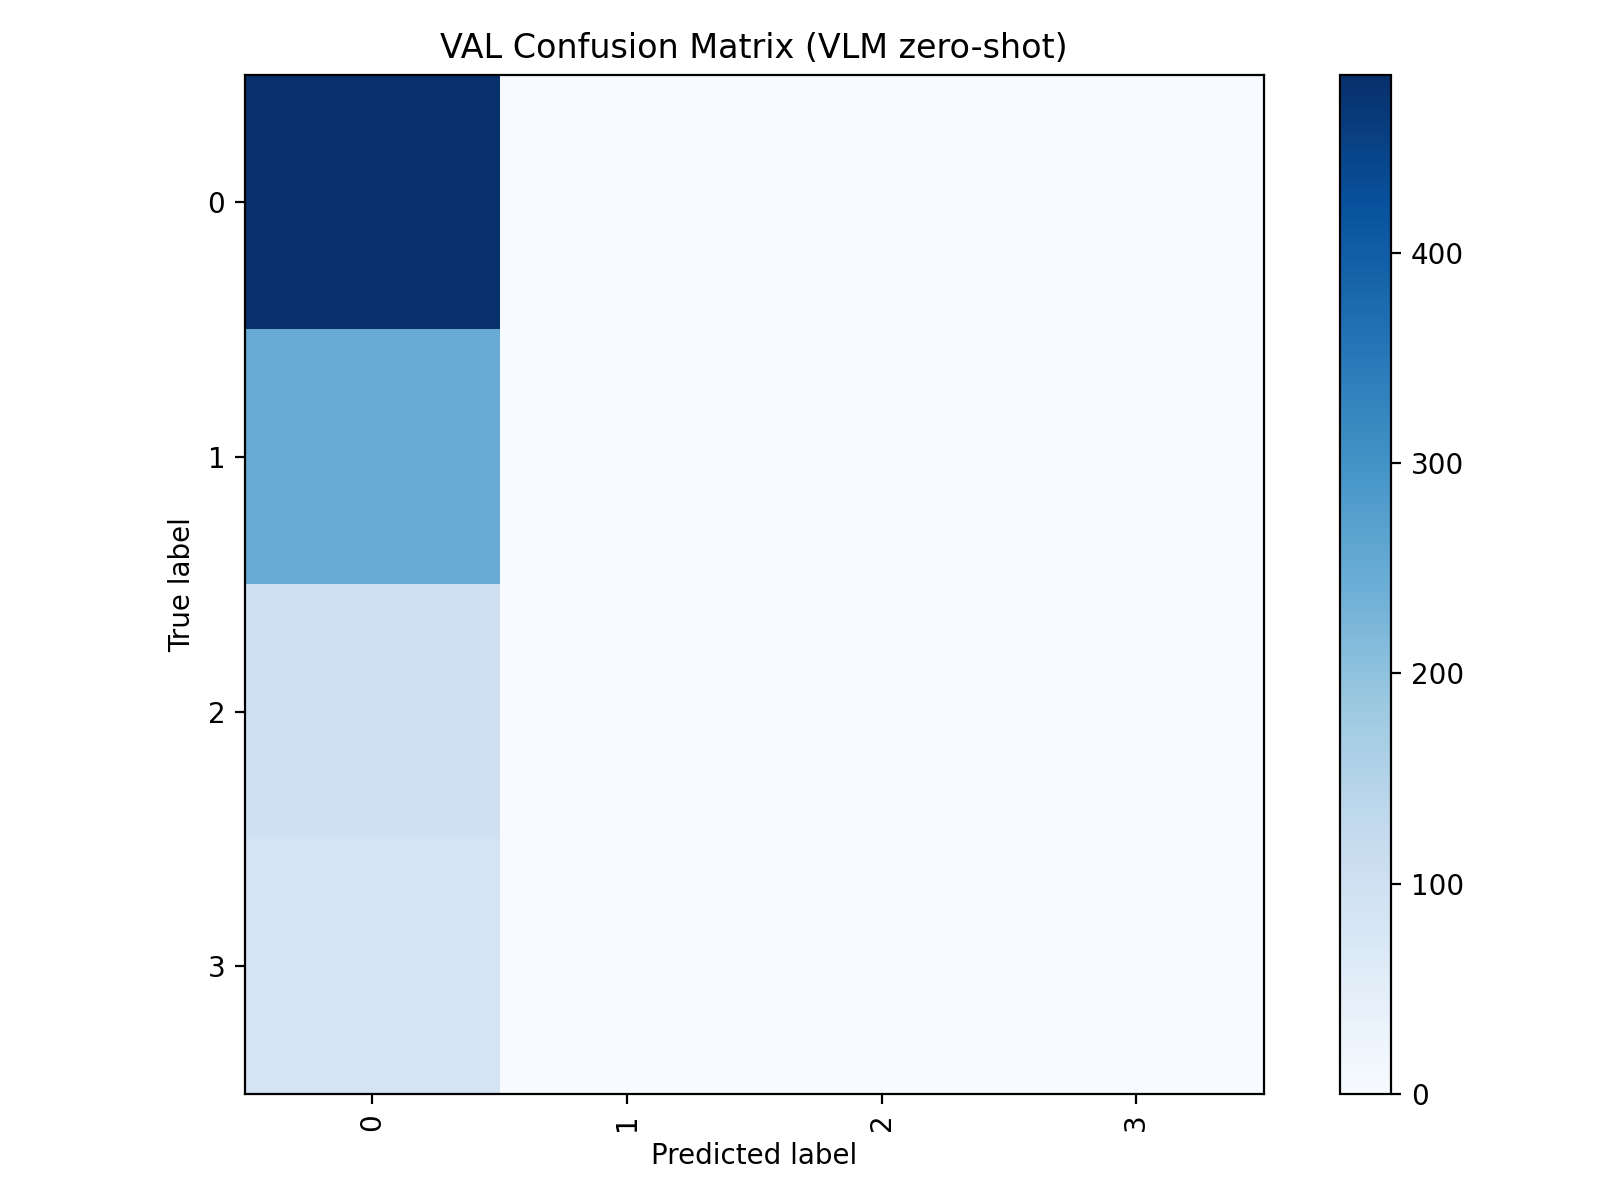


Confusion (test):


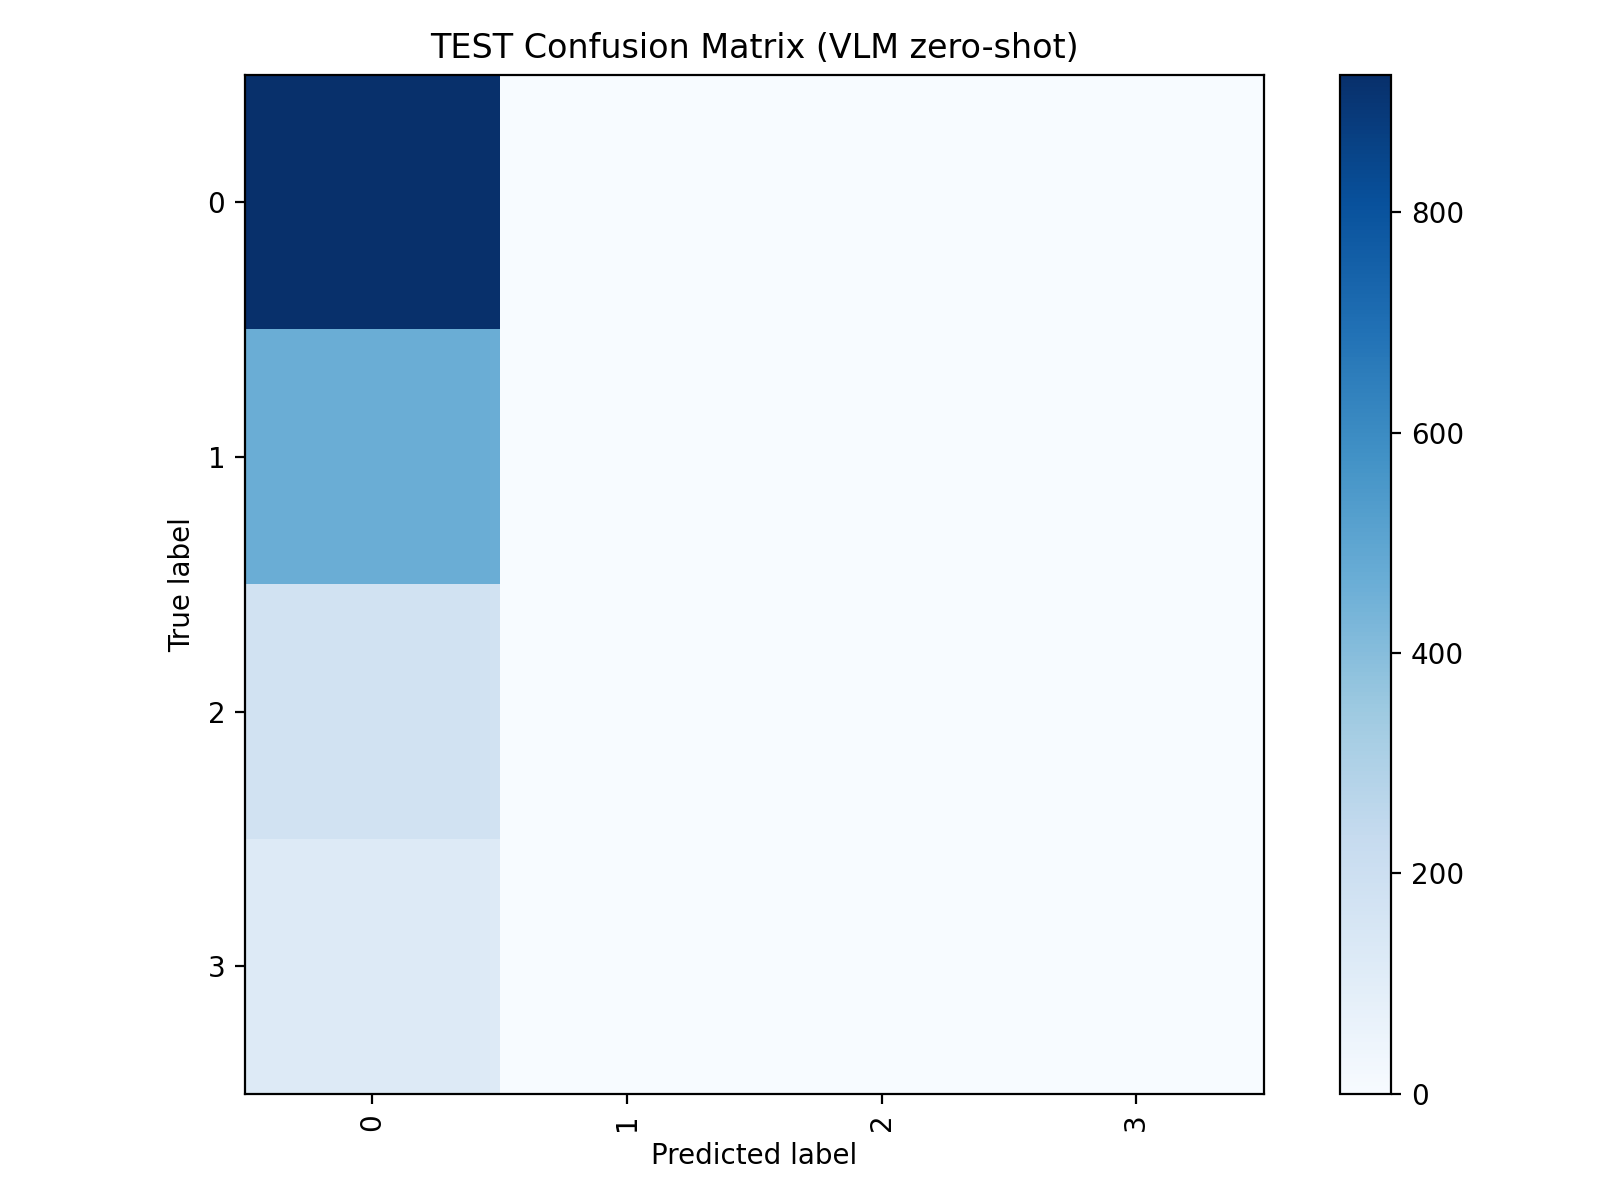

Saved outputs to /mnt/hf/thesis/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/LIMUC/3_vlm_severity/out/vlm_zero_shot_mayo


In [6]:
# =====================
# Results (load if already saved; otherwise compute + save)
# =====================
labels = sorted(id_to_name.keys())
label_names = [id_to_name[i] for i in labels]

pred_val_path = OUT_DIR / "pred_val.csv"
pred_test_path = OUT_DIR / "pred_test.csv"
raw_val_path = OUT_DIR / "pred_val_raw.csv"
raw_test_path = OUT_DIR / "pred_test_raw.csv"
metrics_val_path = OUT_DIR / "metrics_val.json"
metrics_test_path = OUT_DIR / "metrics_test.json"
conf_val_path = OUT_DIR / "confusion_val.npy"
conf_test_path = OUT_DIR / "confusion_test.npy"


def _load_json(path: Path):
    if path.exists():
        return json.loads(path.read_text())
    return None


def _print_summary(name, metrics_json):
    if not metrics_json:
        print(f"{name} summary: <missing>")
        return
    print(f"{name} summary:")
    print(json.dumps(metrics_json.get("summary", {}), indent=2))


if pred_val_path.exists() and pred_test_path.exists() and metrics_val_path.exists() and metrics_test_path.exists():
    val_metrics = _load_json(metrics_val_path)
    test_metrics = _load_json(metrics_test_path)

    _print_summary("Val", val_metrics)
    _print_summary("Test", test_metrics)

    print("")
    print("Pred files:")
    print(" -", pred_val_path)
    print(" -", pred_test_path)
    if raw_val_path.exists() and raw_test_path.exists():
        print("Raw pred files:")
        print(" -", raw_val_path)
        print(" -", raw_test_path)
else:
    if "run_split" not in globals():
        raise RuntimeError("run_split is not defined. Run the model setup cell first.")
    if "val_df" not in globals() or "test_df" not in globals():
        raise RuntimeError("val_df/test_df are not defined. Run the data loading cell first.")

    print("Saved outputs not found; running inference + metrics...")
    y_val, pred_val, text_val = run_split(val_df)
    y_test, pred_test, text_test = run_split(test_df)

    val_out = val_df.copy()
    val_out["y_true"] = y_val
    val_out["y_pred"] = pred_val
    val_out["raw_text"] = text_val
    val_out.to_csv(raw_val_path, index=False)

    test_out = test_df.copy()
    test_out["y_true"] = y_test
    test_out["y_pred"] = pred_test
    test_out["raw_text"] = text_test
    test_out.to_csv(raw_test_path, index=False)

    val_summary, _ = save_split_outputs("val", y_val, pred_val, labels, label_names, OUT_DIR, y_prob=None, df_meta=val_df)
    test_summary, _ = save_split_outputs("test", y_test, pred_test, labels, label_names, OUT_DIR, y_prob=None, df_meta=test_df)

    print("Val summary:")
    print(json.dumps(val_summary, indent=2))
    print("Test summary:")
    print(json.dumps(test_summary, indent=2))

    val_cm = confusion_matrix(y_val, pred_val, labels=labels)
    test_cm = confusion_matrix(y_test, pred_test, labels=labels)
    np.save(conf_val_path, val_cm)
    np.save(conf_test_path, test_cm)

    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay

    for split_name, cm in [("val", val_cm), ("test", test_cm)]:
        fig, ax = plt.subplots(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
        disp.plot(include_values=False, cmap="Blues", ax=ax, xticks_rotation=90)
        plt.title(f"{split_name.upper()} Confusion Matrix (VLM zero-shot)")
        plt.tight_layout()
        fig_path = OUT_DIR / f"confusion_{split_name}.png"
        plt.savefig(fig_path, dpi=200)
        plt.close(fig)

try:
    from IPython.display import display
    from PIL import Image as PILImage

    if (OUT_DIR / "confusion_val.png").exists():
        print("")
        print("Confusion (val):")
        display(PILImage.open(OUT_DIR / "confusion_val.png"))
    if (OUT_DIR / "confusion_test.png").exists():
        print("")
        print("Confusion (test):")
        display(PILImage.open(OUT_DIR / "confusion_test.png"))
except Exception:
    pass

run_meta = {
    "model": "vlm_zero_shot",
    "model_name": MODEL_NAME,
    "prompt": PROMPT,
    "seed": SEED,
    "split_hash": (DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "split_hash.txt").read_text().strip()
        if (DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "split_hash.txt").exists() else None,
}
with open(OUT_DIR / "run_meta.json", "w") as f:
    json.dump(run_meta, f, indent=2)

print("Saved outputs to", OUT_DIR)
